In [1]:
from aoespy import *

/home6/afahad/.local/lib/python3.9/site-packages/aoespy.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
import xarray as xr

In [3]:
import ecco_v4_py as ecco
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from glob import glob
import os


#

In [4]:
def readmit(exp='GEOSMIT35_ctrl',loc='/nobackupp27/afahad/exp/',var=1,start_date='20050501',nfiles=120,freq='D',nz=50, nf=6, ni=90, nj=90, ntile=13,expdir='../mit_output/'):
    
    input_dir = '/nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02'
    input_file = 'bathy_eccollc_90x50_min2pts.bin'
    os.chdir(loc+exp+'/plot')
    pdir='../plots_CLIM/ocean_mit/'
    vdir='/nobackupp27/afahad/mit_diag/'
    try:
        os.system('mkdir -p '+pdir)
    except:
        None

    bathy = ecco.read_llc_to_tiles(input_dir, input_file)

    ecco_grid = ecco.load_ecco_grid_nc(input_dir, 'ECCO-GRID.nc')


    
    restarts='../restarts/'

    os.chdir(expdir)
    files=np.array(sorted(glob('state_3d_set1*.data'))[0:nfiles])
    time=pd.date_range(start_date,periods=len(files),freq=freq)
    
    djf_files=files

    nt=len(time); 

    ndjf=len(djf_files)

    theta_djf=np.zeros((ndjf,nz,ntile,nj,ni)); theta_djf[:]=np.nan
    
    print('reading files')
    for i in range(ndjf):
        print(djf_files[i])
        data=ecco.read_llc_to_tiles(expdir, djf_files[i], nk=-1,nl=-1)
        print(data.shape)
        data=np.reshape(data, (nf,nz,ntile,nj,ni))
        theta_djf[i,:,:,:]=data[var,:,:,:,:]
    return (theta_djf, time)
    
def llc2grd(theta_djf,nz=50):
    input_dir = '/nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02'
    input_file = 'bathy_eccollc_90x50_min2pts.bin'
    ecco_grid = ecco.load_ecco_grid_nc(input_dir, 'ECCO-GRID.nc')
    theta_djf_all=np.zeros(theta_djf.shape)
    theta_djf_all[:]=theta_djf

    new_grid_delta_lat = 1
    new_grid_delta_lon = 1

    new_grid_min_lat = -90
    new_grid_max_lat = 91

    new_grid_min_lon = -180
    new_grid_max_lon = 180

    new_lat=np.arange(-90,91,1); nlat=len(new_lat)
    new_lon=np.arange(-180,180,1); nlon=len(new_lon)

    tt=len(theta_djf)
    theta_djf_alli=np.zeros((tt,nz,nlat,nlon))

    for i in range(tt):
        for j in range(nz):

            new_grid_lon_centers, new_grid_lat_centers,\
            new_grid_lon_edges, new_grid_lat_edges,\
            theta_djf_alli[i,j,:,:] =\
                    ecco.resample_to_latlon(ecco_grid.XC, \
                                            ecco_grid.YC, \
                                            theta_djf_all[i,j,:,:,:],\
                                            new_grid_min_lat, new_grid_max_lat, new_grid_delta_lat,\
                                            new_grid_min_lon, new_grid_max_lon, new_grid_delta_lon,\
                                            fill_value = np.NaN, \
                                            mapping_method = 'nearest_neighbor',
                                            radius_of_influence = 120000)
    return (np.squeeze(theta_djf_alli), new_lon, new_lat)


In [5]:
ME421, time=readmit('GEOSMIT_ME0421',nz=50,nfiles=120,freq='12H',start_date='20050501', )
ME421=ME421[:,0:1,:,:,:]
ME421,lon,lat=llc2grd(ME421,nz=1)

RP421, time=readmit('GEOSMIT_RP0421',nz=50,nfiles=120,freq='12H',start_date='20050501', )
RP421=RP421[:,0:1,:,:,:]
RP421,lon,lat=llc2grd(RP421,nz=1)

load_binary_array: loading file /nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02/bathy_eccollc_90x50_min2pts.bin
load_binary_array: data array shape  (1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
reading files
state_3d_set1.0000000060.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000000060.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000000156.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000000156.data
load_binary

llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000001692.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000001692.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000001788.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000001788.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
ll

llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000003420.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000003420.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000003516.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000003516.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
ll

llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000005148.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000005148.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000005244.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000005244.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
ll

llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000006876.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000006876.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000006972.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000006972.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
ll

...

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000016956.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000016956.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000017052.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000017052.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000018684.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000018684.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000018780.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000018780.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000020412.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000020412.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000020508.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000020508.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000022140.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000022140.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000022236.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000022236.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000023868.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000023868.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000023964.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000023964.data
load_binary_array: loading all 2D records.  nk = 300
load_

In [6]:

ME501, time1=readmit('GEOSMIT_ME0501',nz=50,nfiles=120,freq='12H',start_date='20050501', )
ME501=ME501[:,0:1,:,:,:]
ME501,lon,lat=llc2grd(ME501,nz=1)

RP501, time1=readmit('GEOSMIT_RP0501',nz=50,nfiles=120,freq='12H',start_date='20050501', )
RP501=RP501[:,0:1,:,:,:]
RP501,lon,lat=llc2grd(RP501,nz=1)

load_binary_array: loading file /nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02/bathy_eccollc_90x50_min2pts.bin
load_binary_array: data array shape  (1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
reading files
state_3d_set1.0000000060.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000000060.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000000156.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000000156.data
load_binary

llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000001692.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000001692.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000001788.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000001788.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
ll

llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000003420.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000003420.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000003516.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000003516.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
ll

llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000005148.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000005148.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000005244.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000005244.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
ll

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000006876.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000006876.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000006972.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000006972.data
load_binary_array: loading all 2D records.  nk = 300
load_

...

llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000018780.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000018780.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000018876.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000018876.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
ll

llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000020508.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000020508.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000020604.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000020604.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
ll

llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000022236.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000022236.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000022332.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000022332.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
ll

llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000023964.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000023964.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000024060.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000024060.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
ll

llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000025692.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000025692.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000025788.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000025788.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
ll

In [7]:
ME416, time=readmit('GEOSMIT_ME0416',nz=50,nfiles=120,freq='12H',start_date='20050501', )
ME416=ME416[:,0:1,:,:,:]
ME416,lon,lat=llc2grd(ME416,nz=1)

RP416, time=readmit('GEOSMIT_RP0416',nz=50,nfiles=120,freq='12H',start_date='20050501', )
RP416=RP416[:,0:1,:,:,:]
RP416,lon,lat=llc2grd(RP416,nz=1)


load_binary_array: loading file /nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02/bathy_eccollc_90x50_min2pts.bin
load_binary_array: data array shape  (1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
reading files
state_3d_set1.0000000060.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000000060.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000000156.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000000156.data
load_binary

llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000001692.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000001692.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000001788.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000001788.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
ll

llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000003420.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000003420.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000003516.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000003516.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
ll

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000005148.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000005148.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000005244.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000005244.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000006876.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000006876.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000006972.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000006972.data
load_binary_array: loading all 2D records.  nk = 300
load_

...

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000015900.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000015900.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000015996.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000015996.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000017628.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000017628.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000017724.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000017724.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000019356.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000019356.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000019452.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000019452.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000021084.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000021084.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000021180.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000021180.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000022812.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000022812.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000022908.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000022908.data
load_binary_array: loading all 2D records.  nk = 300
load_

In [8]:
ME426, time=readmit('GEOSMIT_ME0426',nz=50,nfiles=120,freq='12H',start_date='20050501', )
ME426=ME426[:,0:1,:,:,:]
ME426,lon,lat=llc2grd(ME426,nz=1)

RP426, time=readmit('GEOSMIT_RP0426',nz=50,nfiles=120,freq='12H',start_date='20050501', )
RP426=RP426[:,0:1,:,:,:]
RP426,lon,lat=llc2grd(RP426,nz=1)

load_binary_array: loading file /nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02/bathy_eccollc_90x50_min2pts.bin
load_binary_array: data array shape  (1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
reading files
state_3d_set1.0000000060.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000000060.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000000156.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000000156.data
load_binary

llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000001692.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000001692.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000001788.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000001788.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
ll

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000003420.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000003420.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000003516.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000003516.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000005148.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000005148.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000005244.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000005244.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000006876.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000006876.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000006972.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000006972.data
load_binary_array: loading all 2D records.  nk = 300
load_

...

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000017820.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000017820.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000017916.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000017916.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000019548.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000019548.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000019644.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000019644.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000021276.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000021276.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000021372.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000021372.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000023004.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000023004.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000023100.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000023100.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000024732.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000024732.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000024828.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000024828.data
load_binary_array: loading all 2D records.  nk = 300
load_

In [9]:

ME506, time1=readmit('GEOSMIT_ME0506',nz=50,nfiles=120,freq='12H',start_date='20050501', )
ME506=ME506[:,0:1,:,:,:]
ME506,lon,lat=llc2grd(ME506,nz=1)

RP506, time1=readmit('GEOSMIT_RP0506',nz=50,nfiles=120,freq='12H',start_date='20050501', )
RP506=RP506[:,0:1,:,:,:]
RP506,lon,lat=llc2grd(RP506,nz=1)

load_binary_array: loading file /nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02/bathy_eccollc_90x50_min2pts.bin
load_binary_array: data array shape  (1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
reading files
state_3d_set1.0000000060.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000000060.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000000156.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000000156.data
load_binary

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000001788.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000001788.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000001884.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000001884.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000003516.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000003516.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000003612.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000003612.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000005244.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000005244.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000005340.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000005340.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000006972.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000006972.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000007068.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000007068.data
load_binary_array: loading all 2D records.  nk = 300
load_

...

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000019836.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000019836.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000019932.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000019932.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000021564.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000021564.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000021660.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000021660.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000023292.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000023292.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000023388.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000023388.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000025020.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000025020.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000025116.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000025116.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000026748.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000026748.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000026844.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000026844.data
load_binary_array: loading all 2D records.  nk = 300
load_

In [10]:

ME511, time1=readmit('GEOSMIT_ME0511',nz=50,nfiles=120,freq='12H',start_date='20050501', )
ME511=ME511[:,0:1,:,:,:]
ME511,lon,lat=llc2grd(ME511,nz=1)

RP511, time1=readmit('GEOSMIT_RP0511',nz=50,nfiles=120,freq='12H',start_date='20050501', )
RP511=RP511[:,0:1,:,:,:]
RP511,lon,lat=llc2grd(RP511,nz=1)

load_binary_array: loading file /nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02/bathy_eccollc_90x50_min2pts.bin
load_binary_array: data array shape  (1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
reading files
state_3d_set1.0000000060.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000000060.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000000156.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000000156.data
load_binary

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000001788.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000001788.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000001884.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000001884.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000003516.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000003516.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000003612.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000003612.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000005244.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000005244.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000005340.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000005340.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000006972.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000006972.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000007068.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000007068.data
load_binary_array: loading all 2D records.  nk = 300
load_

...

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000020796.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000020796.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000020892.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000020892.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000022524.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000022524.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000022620.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000022620.data
load_binary_array: loading all 2D records.  nk = 300
load_

llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000024156.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000024156.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000024252.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000024252.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
ll

llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000025884.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000025884.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000025980.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000025980.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
ll

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000027612.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000027612.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000027708.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000027708.data
load_binary_array: loading all 2D records.  nk = 300
load_

In [11]:
ds = xr.Dataset(
    {
        "ME416": (["time", "lat", "lon"], ME416),
        "RP416": (["time", "lat", "lon"], RP416),
        
        "ME421": (["time", "lat", "lon"], ME421),
        "RP421": (["time", "lat", "lon"], RP421),
        
        "ME426": (["time", "lat", "lon"], ME426),
        "RP426": (["time", "lat", "lon"], RP426),
        
        "ME501": (["time", "lat", "lon"], ME501),
        "RP501": (["time", "lat", "lon"], RP501),
        "ME506": (["time", "lat", "lon"], ME506),
        "RP506": (["time", "lat", "lon"], RP506),
        "ME511": (["time", "lat", "lon"], ME511),
        "RP511": (["time", "lat", "lon"], RP511)
    },
    coords={
        "time": time,
        "lat": lat,
        "lon": lon
    }
)

ME416=ds.ME416
RP416=ds.RP416

ME421=ds.ME421
RP421=ds.RP421

ME426=ds.ME426
RP426=ds.RP426

ME501=ds.ME501
RP501=ds.RP501

ME506=ds.ME506
RP506=ds.RP506

ME511=ds.ME511
RP511=ds.RP511


In [14]:
dir='/nobackupp27/afahad/exp/script_replay_AGU/data/ecco/'
eTHETA=xr.open_mfdataset(dir+'THETA_2005_0*.nc').THETA.compute()
eTHETA=eTHETA[:,0:1,:,:,:]
THETA,lon,lat=llc2grd(eTHETA,nz=1)

ds = xr.Dataset(
    {
        "THETA": (["time", "lat", "lon"], THETA),
    },
    coords={
        "time": eTHETA.time,
        "lat": lat,
        "lon": lon
    }
)

theta= ds.THETA

In [15]:
ME416=ME416.resample(time='1D').mean()
RP416=RP416.resample(time='1D').mean()

ME421=ME421.resample(time='1D').mean()
RP421=RP421.resample(time='1D').mean()

ME426=ME426.resample(time='1D').mean()
RP426=RP426.resample(time='1D').mean()

ME501=ME501.resample(time='1D').mean()
RP501=RP501.resample(time='1D').mean()


ME506=ME506.resample(time='1D').mean()
RP506=RP506.resample(time='1D').mean()

ME511=ME511.resample(time='1D').mean()
RP511=RP511.resample(time='1D').mean()

In [16]:
#Bias

BME416=ME416-theta.sel(time=slice('2005-04-16','2005-06-15')).data

BME421=ME421-theta.sel(time=slice('2005-04-21','2005-06-20')).data

BME426=ME426-theta.sel(time=slice('2005-04-26','2005-06-25')).data

BME501=ME501-theta.sel(time=slice('2005-05-01','2005-06-30')).data

BME506=ME506-theta.sel(time=slice('2005-05-06','2005-07-05')).data

BME511=ME511-theta.sel(time=slice('2005-05-11','2005-07-10')).data

In [17]:
#Bias

BRP416=RP416-theta.sel(time=slice('2005-04-16','2005-06-15')).data

BRP421=RP421-theta.sel(time=slice('2005-04-21','2005-06-20')).data

BRP426=RP426-theta.sel(time=slice('2005-04-26','2005-06-25')).data

BRP501=RP501-theta.sel(time=slice('2005-05-01','2005-06-30')).data

BRP506=RP506-theta.sel(time=slice('2005-05-06','2005-07-05')).data

BRP511=RP511-theta.sel(time=slice('2005-05-11','2005-07-10')).data


In [18]:
# BRP=(BRP416+BRP421+BRP426+BRP501+BRP506+BRP511)/6
# BME=(BME416+BME421+BME426+BME501+BME506+BME511)/6

# BRP=(BRP426)#+BRP421+BRP426+BRP501)/4
# BME=(BME426)#+BME421+BME426+BME501)/4

BRP=(BRP426+BRP501+BRP506+BRP511)/4
BME=(BME426+BME501+BME506+BME511)/4

# BRP=(BRP506+BRP511)/2
# BME=(BME506+BME511)/2

In [155]:
# x1=-35
# x2=-25
# y1=25
# y2=30

# plt.figure(figsize=(16,8))

# plt.subplot(2,2,1)
# plt.plot((BME).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='blue',linewidth=1.5)
# plt.plot((BRP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='red',linewidth=1.5)
# plt.plot(zeros(len(BME416)),color='black')

# plt.plot((BME416).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP416).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)


# plt.plot((BME421).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP421).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

# plt.plot((BME426).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP426).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

# plt.plot((BME501).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP501).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)


# plt.plot((BME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

# plt.plot((BME511).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP511).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

# plt.title('North Atlantic')

# plt.subplot(2,2,2)

# x1=160
# x2=170
# y1=-20
# y2=-10

# plt.plot((BME).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='blue',linewidth=1.5)
# plt.plot((BRP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='red',linewidth=1.5)
# plt.plot(zeros(len(BME416)),color='black')

# plt.plot((BME416).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP416).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)


# plt.plot((BME421).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP421).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

# plt.plot((BME426).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP426).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

# plt.plot((BME501).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP501).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

# plt.plot((BME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

# plt.plot((BME511).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP511).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)


# plt.title('SPCZ')


# plt.subplot(2,2,3)
# x1=80
# x2=85
# y1=-5
# y2=5

# plt.plot((BME).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='blue',linewidth=1.5)
# plt.plot((BRP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='red',linewidth=1.5)
# plt.plot(zeros(len(BME416)),color='black')

# plt.plot((BME416).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP416).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)


# plt.plot((BME421).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP421).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

# plt.plot((BME426).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP426).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

# plt.plot((BME501).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP501).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

# plt.plot((BME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

# plt.plot((BME511).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP511).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

# plt.title('Indian Ocean')




# plt.subplot(2,2,4)
# x1=120
# x2=140
# y1=25
# y2=30

# plt.plot((BME).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='blue',linewidth=1.5)
# plt.plot((BRP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='red',linewidth=1.5)
# plt.plot(zeros(len(BME416)),color='black')

# plt.plot((BME416).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP416).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)


# plt.plot((BME421).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP421).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

# plt.plot((BME426).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP426).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

# plt.plot((BME501).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP501).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

# plt.plot((BME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

# plt.plot((BME511).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP511).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

# plt.title('West Pacific')

In [43]:
# BRP=(BRP416+BRP421+BRP426+BRP501+BRP506+BRP511)/6
# BME=(BME416+BME421+BME426+BME501+BME506+BME511)/6

# BRP=(BRP426+BRP501+BRP511)/3
# BME=(BME426+BME501+BME511)/3

# BRP=(BRP426+BRP501+BRP506+BRP511)/4
# BME=(BME426+BME501+BME506+BME511)/4

BRP=(BRP426+BRP506+BRP511)/3
BME=(BME426+BME506+BME511)/3

BME[0,:,:]=0

# BRPSTD=nanstd((BRP426+BRP501+BRP511),axis=0)
# BMESTD=nanstd((BME426+BME501+BME511),axis=0)

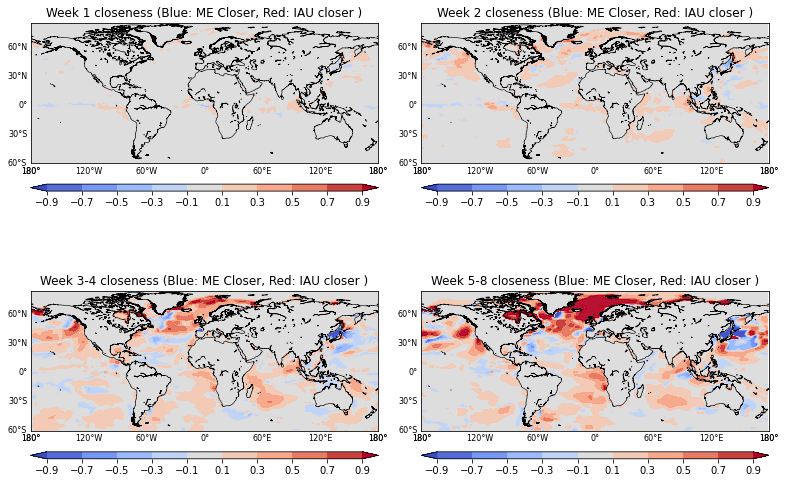

In [44]:
plt.figure(figsize=(11,8))

clf=arange(-.9,.91,.2)

plt.subplot(2,2,1)
plot(abs(BME.sel(time=slice('2005-05-01','2005-05-07')).mean(dim='time'))-abs(BRP.sel(time=slice('2005-05-01','2005-05-07')).mean(dim='time')),lon1=-180,lon2=180,lat1=-60,lat2=85,clf=clf);
plt.title('Week 1 closeness (Blue: ME Closer, Red: IAU closer )')

# clf=arange(-.45,.451,.05)
plt.subplot(2,2,2)
plot(abs(BME.sel(time=slice('2005-05-08','2005-05-14')).mean(dim='time'))-abs(BRP.sel(time=slice('2005-05-08','2005-05-14')).mean(dim='time')),lon1=-180,lon2=180,lat1=-60,lat2=85,clf=clf);
plt.title('Week 2 closeness (Blue: ME Closer, Red: IAU closer )')


# clf=arange(-.55,.551,.1)

plt.subplot(2,2,3)
plot(abs(BME.sel(time=slice('2005-05-15','2005-05-30')).mean(dim='time'))-abs(BRP.sel(time=slice('2005-05-15','2005-05-30')).mean(dim='time')),lon1=-180,lon2=180,lat1=-60,lat2=85,clf=clf);
plt.title('Week 3-4 closeness (Blue: ME Closer, Red: IAU closer )')


# clf=arange(-2.25,2.251,.5)

plt.subplot(2,2,4)
plot(abs(BME.sel(time=slice('2005-06-01','2005-06-30')).mean(dim='time'))-abs(BRP.sel(time=slice('2005-06-01','2005-06-30')).mean(dim='time')),lon1=-180,lon2=180,lat1=-60,lat2=85,clf=clf);
plt.title('Week 5-8 closeness (Blue: ME Closer, Red: IAU closer )')

plt.tight_layout()
#plt.savefig('/nobackupp27/afahad/scripts/initialization_shock/closeness_week.png',dpi=200)


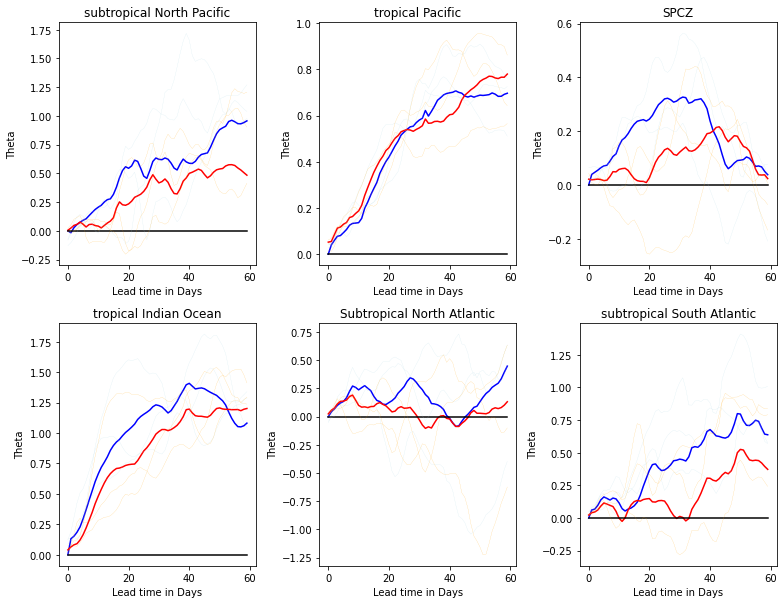

In [78]:


plt.figure(figsize=(11,8.5))

x1=-140
x2=-120
y1=28
y2=35

plt.subplot(2,3,1)
plt.plot((BME).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='blue',linewidth=1.5)
plt.plot((BRP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='red',linewidth=1.5)
plt.plot(zeros(len(BME416)),color='black')

# plt.plot((BME416).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP416).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)


# plt.plot((BME421).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP421).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

plt.plot((BME426).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
plt.plot((BRP426).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

plt.plot((BME501).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
plt.plot((BRP501).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)


plt.plot((BME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
plt.plot((BRP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

# plt.plot((BME511).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP511).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)
#plt.ylim(-.75,2)
plt.xlabel('Lead time in Days')
plt.ylabel('Theta')
plt.title('subtropical North Pacific')



x3=-180
x4=-170
y3=-5
y4=5

x1=120
x2=180
y1=-5
y2=5



plt.subplot(2,3,2)

# plt.plot((BME).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='blue',linewidth=1.5)
# plt.plot((BRP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='red',linewidth=1.5)

plt.plot(((BME).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon'])+(BME).sel(lat=slice(y3,y4),lon=slice(x3,x4)).mean(dim=['lat','lon']))/2,color='blue',linewidth=1.5)
plt.plot(((BRP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon'])+(BRP).sel(lat=slice(y3,y4),lon=slice(x3,x4)).mean(dim=['lat','lon']))/2,color='red',linewidth=1.5)
plt.plot(zeros(len(BME416)),color='black')

# plt.plot((BME416).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP416).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)


# plt.plot((BME421).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP421).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

plt.plot((BME426).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
plt.plot((BRP426).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

plt.plot((BME501).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
plt.plot((BRP501).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)


plt.plot((BME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
plt.plot((BRP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

# plt.plot((BME511).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP511).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)
#plt.ylim(-.75,2)
plt.xlabel('Lead time in Days')
plt.ylabel('Theta')
plt.title('tropical Pacific')


x1=140
x2=170
y1=-20
y2=-15

plt.subplot(2,3,3)
plt.plot((BME).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='blue',linewidth=1.5)
plt.plot((BRP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='red',linewidth=1.5)
plt.plot(zeros(len(BME416)),color='black')

# plt.plot((BME416).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP416).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)


# plt.plot((BME421).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP421).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

plt.plot((BME426).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
plt.plot((BRP426).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

plt.plot((BME501).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
plt.plot((BRP501).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)


plt.plot((BME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
plt.plot((BRP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

# plt.plot((BME511).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP511).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)
#plt.ylim(-.75,2)
plt.xlabel('Lead time in Days')
plt.ylabel('Theta')
plt.title('SPCZ')



x1=80
x2=100
y1=-1
y2=5

plt.subplot(2,3,4)
plt.plot((BME).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='blue',linewidth=1.5)
plt.plot((BRP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='red',linewidth=1.5)
plt.plot(zeros(len(BME416)),color='black')

# plt.plot((BME416).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP416).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)


# plt.plot((BME421).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP421).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

plt.plot((BME426).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
plt.plot((BRP426).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

plt.plot((BME501).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
plt.plot((BRP501).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)


plt.plot((BME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
plt.plot((BRP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

# plt.plot((BME511).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP511).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)
#plt.ylim(-.75,2)
plt.xlabel('Lead time in Days')
plt.ylabel('Theta')
plt.title('tropical Indian Ocean')




x1=-33
x2=-25
y1=20
y2=30

plt.subplot(2,3,5)
plt.plot((BME).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='blue',linewidth=1.5)
plt.plot((BRP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='red',linewidth=1.5)
plt.plot(zeros(len(BME416)),color='black')


# plt.plot((BME416).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP416).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)


# plt.plot((BME421).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP421).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

plt.plot((BME426).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
plt.plot((BRP426).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

plt.plot((BME501).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
plt.plot((BRP501).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)


plt.plot((BME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
plt.plot((BRP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

# plt.plot((BME511).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP511).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)
#plt.ylim(-.75,2)
plt.xlabel('Lead time in Days')
plt.ylabel('Theta')
plt.title('Subtropical North Atlantic')


x1=5
x2=8
y1=-27
y2=-15

plt.subplot(2,3,6)
plt.plot((BME).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='blue',linewidth=1.5)
plt.plot((BRP).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='red',linewidth=1.5)
plt.plot(zeros(len(BME416)),color='black')

# plt.plot((BME416).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP416).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)


# plt.plot((BME421).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP421).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

plt.plot((BME426).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
plt.plot((BRP426).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

plt.plot((BME501).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
plt.plot((BRP501).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)


plt.plot((BME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
plt.plot((BRP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

# plt.plot((BME511).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='lightblue',alpha=.6,linewidth=.2)
# plt.plot((BRP511).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lat','lon']),color='orange',alpha=.6,linewidth=.2)

#plt.ylim(-.75,2)
plt.xlabel('Lead time in Days')
plt.ylabel('Theta')
plt.title('subtropical South Atlantic')

plt.tight_layout()
plt.savefig('/nobackupp27/afahad/scripts/initialization_shock/Lead_bias.png',dpi=150)